# Fourier Optics Lab

In [301]:
### Load in the data and all programs

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft2, ifft2, fftshift
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d, gaussian_filter

image = Image.open("Airy_pattern.png")
experiment_image = Image.open("Slide 33 No Filter.png")
lpf_experiment_image = Image.open("LowPass Slide 33 Dot F.png")
hpf_experiment_image = Image.open("High  Pass Slide 33 Dot G 2.png")
lpf_C_experiment_image = Image.open("Low Pass Slide 33 Dot C.jpg")

data = np.array(image)
experiment_data = np.array(experiment_image)
lpf_experiment_data = np.array(lpf_experiment_image)
hpf_experiment_data = np.array(hpf_experiment_image)
lpf_C_experiment_data = np.array(hpf_experiment_image)

data = data[..., :3].mean(axis=2)
noise_level = 1500   # amplitude of noise
blur_sigma = 10      # controls how "large" the blobs are
low_freq_noise = gaussian_filter(np.random.normal(scale=noise_level, size=data.shape),
                                 sigma=blur_sigma)

# Add noise to image
data = data + low_freq_noise
fft_data = fft2(data)
fft_data = fftshift(fft_data)
#fig, axs = plt.subplots(nrows=4, ncols=2)

experiment_data = experiment_data[..., :3].mean(axis=2)
ex_fft_data = fft2(experiment_data)
ex_fft_data = fftshift(ex_fft_data)

lpf_experiment_data = lpf_experiment_data[..., :3].mean(axis=2)
ex_lpf_fft_data = fft2(lpf_experiment_data)
ex_lpf_fft_data = fftshift(ex_lpf_fft_data)

hpf_experiment_data = hpf_experiment_data[..., :3].mean(axis=2)
ex_hpf_fft_data = fft2(hpf_experiment_data)
ex_hpf_fft_data = fftshift(ex_hpf_fft_data)

lpf_C_experiment_data = lpf_C_experiment_data[..., :3].mean(axis=2)
ex_lpf_C_fft_data = fft2(lpf_C_experiment_data)
ex_lpf_C_fft_data = fftshift(ex_lpf_C_fft_data)

# Fourier Analysis

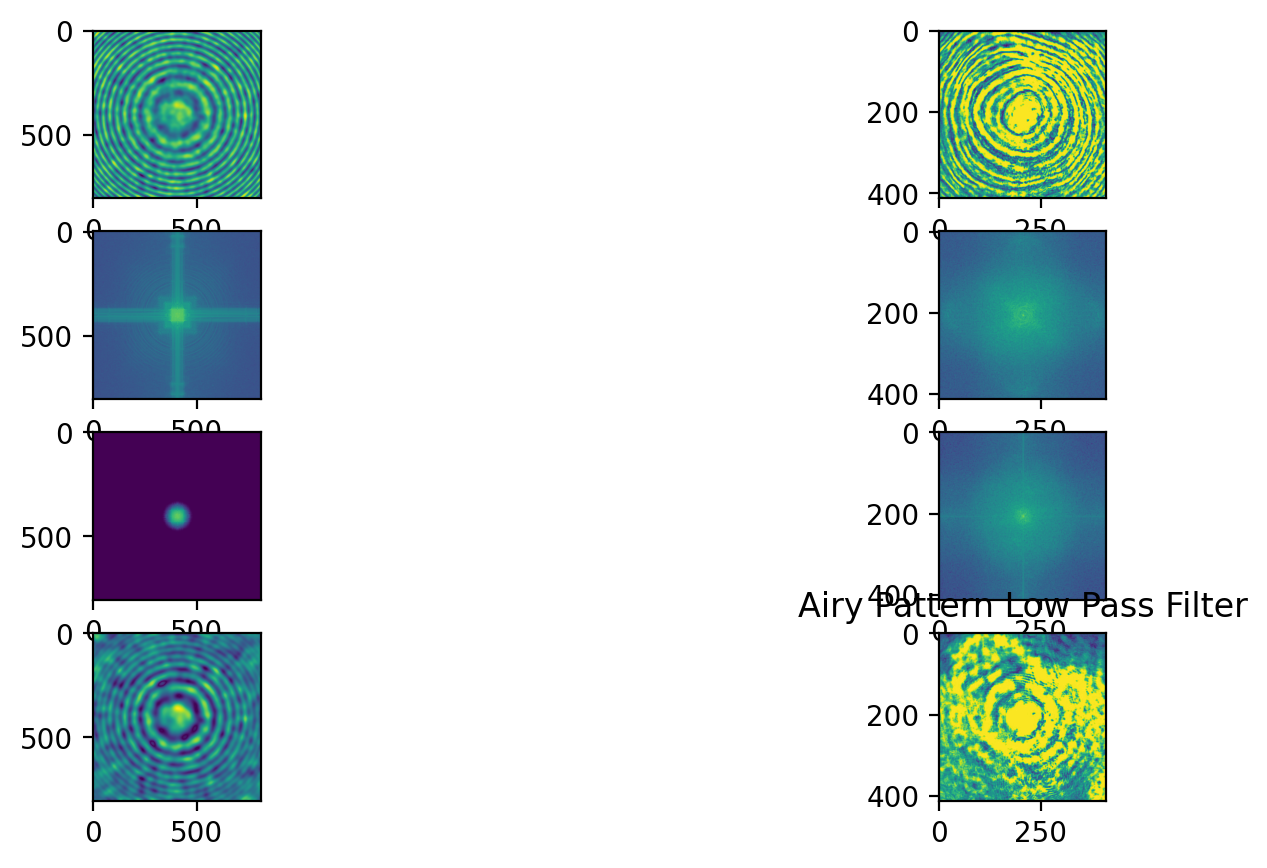

In [307]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(10,5), dpi=200)

ny, nx = data.shape
y, x = np.indices((ny,nx))

cy, cx = ny//2, nx//2
r = np.sqrt((x - cx)**2 + (y - cy)**2)

#r_cutoff  = 9 # Airy_patter
r_cutoff = 30
# mask = r <= r_cutoff

sigma = r_cutoff / 2  # adjust for smoothness
mask = np.exp(-(r**2)/(2*sigma**2))
#F_filtered =  * mask
# sigma = 6  # controls blur strength
# mask = np.exp(-(r**2) / (2 * sigma**2))
F_filtered = fft_data * mask


# NOISE
#noise_level = 200  # adjust for amount of noise
#F_filtered = F_filtered + np.random.normal(scale=noise_level, size=F_filtered.shape)

filtered_image = ifft2(F_filtered)
filtered_image = np.abs(filtered_image)

plt.title("Airy Pattern Low Pass Filter")

# norm = np.linalg.norm(fft_data)
# unit_vector = fft_data / norm

#### Calculated
axs[0,0].imshow(data)
axs[1,0].imshow(np.log1p(np.abs(fft_data)))
axs[2,0].imshow(np.log1p(np.abs(F_filtered)))
axs[3,0].imshow(filtered_image)

axs[0,1].imshow(experiment_data)
axs[1,1].imshow(np.log1p(np.abs(ex_fft_data)))
axs[2,1].imshow(np.log1p(np.abs(ex_lpf_fft_data)))
axs[3,1].imshow(lpf_experiment_data)

#img = Image.fromarray(np.log1p(np.abs(fft_data)))
plt.imsave('data.png', data)
plt.imsave('FFT.png', np.log1p(np.abs(fft_data)))

# print(max(np.abs(ex_fft_data)))
# print(max(np.abs(ex_lpf_fft_data)))

1
hf_ratio for LPF 0.34477784325055394
hf_ratio for Source 0.5554405379437886
LPF power ratio 0.620728628354897


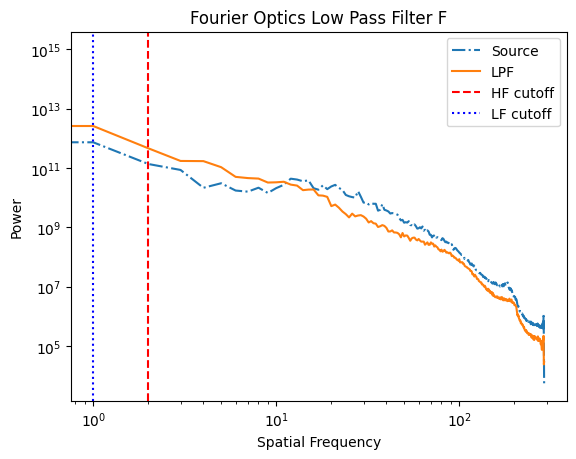

In [246]:
### Lets radially average the Filtered FFTs and compare them
power_source = np.abs(ex_fft_data)**2
power_lpf = np.abs(ex_lpf_fft_data)**2

def get_radial_profile(data):
    ny, nx = data.shape
    y, x = np.indices((ny, nx))
    cy, cx = ny//2, nx//2
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())

    radial_profile = tbin / nr

    return radial_profile

radial_power_source = get_radial_profile(power_source)
radial_power_lpf = get_radial_profile(power_lpf)

# ### NORMAL
# radial_power_source = radial_power_source / np.sum(radial_power_source)
# radial_power_lpf = radial_power_lpf / np.sum(radial_power_lpf)
# radial_power_hpf = radial_power_hpf / np.sum(radial_power_hpf)

half_power = radial_power_lpf[0] / 2

cutoff_idx = np.where(radial_power_lpf < half_power)[0][0]
print(cutoff_idx)

def get_hf_ratio(radial_power, cutoff=20, offset=1):
    hf_power = np.sum(radial_power[cutoff:])
    total_power = np.sum(radial_power[offset:])

    hf_ratio = hf_power / total_power

    return hf_ratio

def half_point(radial_power, offset=1):

    half_peak_power = radial_power[0+offset]/2

    cutoff_idx = np.where(radial_power < half_peak_power)[0][0]

    return cutoff_idx



CUTOFF = 11
OFFSET = 1


CUTOFF = half_point(radial_power_lpf)

print("hf_ratio for LPF", get_hf_ratio(radial_power_lpf,cutoff=CUTOFF))
print("hf_ratio for Source", get_hf_ratio(radial_power_source,cutoff=CUTOFF))

print("LPF power ratio",get_hf_ratio(radial_power_lpf,cutoff=CUTOFF)/get_hf_ratio(radial_power_source,cutoff=CUTOFF))

plt.semilogy(radial_power_source, linestyle="-.", label="Source")
plt.semilogy(radial_power_lpf, label="LPF")
plt.xlabel("Spatial Frequency")
plt.ylabel("Power")
plt.title("Fourier Optics Low Pass Filter F")
plt.axvline(CUTOFF, linestyle='--', color='red', label='HF cutoff')
plt.axvline(OFFSET, linestyle=':', color='blue', label='LF cutoff')
plt.legend()
#plt.xlim(0,100)
plt.xscale("log")

1
hf_ratio for LPF 0.4138639099480751
hf_ratio for Source 0.47275143284868937
LPF power ratio 0.8754366061975278


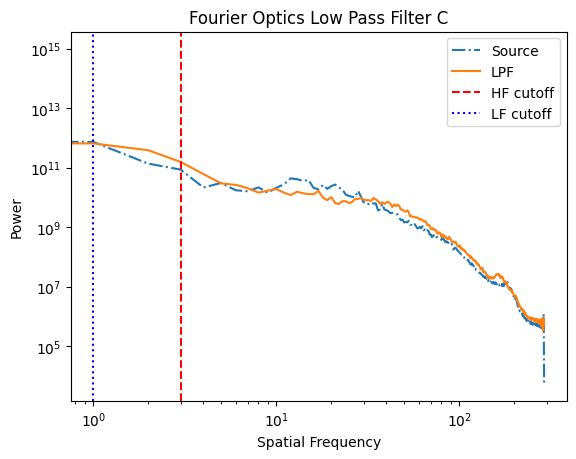

In [247]:
### Lets radially average the Filtered FFTs and compare them
power_source = np.abs(ex_fft_data)**2
power_lpf = np.abs(ex_lpf_C_fft_data)**2

def get_radial_profile(data):
    ny, nx = data.shape
    y, x = np.indices((ny, nx))
    cy, cx = ny//2, nx//2
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())

    radial_profile = tbin / nr

    return radial_profile

radial_power_source = get_radial_profile(power_source)
radial_power_lpf = get_radial_profile(power_lpf)

# ### NORMAL
# radial_power_source = radial_power_source / np.sum(radial_power_source)
# radial_power_lpf = radial_power_lpf / np.sum(radial_power_lpf)
# radial_power_hpf = radial_power_hpf / np.sum(radial_power_hpf)

half_power = radial_power_lpf[0] / 2

cutoff_idx = np.where(radial_power_lpf < half_power)[0][0]
print(cutoff_idx)

def get_hf_ratio(radial_power, cutoff=20, offset=1):
    hf_power = np.sum(radial_power[cutoff:])
    total_power = np.sum(radial_power[offset:])

    hf_ratio = hf_power / total_power

    return hf_ratio

def half_point(radial_power, offset=1):

    half_peak_power = radial_power[0+offset]/2

    cutoff_idx = np.where(radial_power < half_peak_power)[0][0]

    return cutoff_idx



CUTOFF = 11
OFFSET = 1


CUTOFF = half_point(radial_power_lpf)

print("hf_ratio for LPF", get_hf_ratio(radial_power_lpf,cutoff=CUTOFF))
print("hf_ratio for Source", get_hf_ratio(radial_power_source,cutoff=CUTOFF))

print("LPF power ratio",get_hf_ratio(radial_power_lpf,cutoff=CUTOFF)/get_hf_ratio(radial_power_source,cutoff=CUTOFF))

plt.semilogy(radial_power_source, linestyle="-.", label="Source")
plt.semilogy(radial_power_lpf, label="LPF")
plt.xlabel("Spatial Frequency")
plt.ylabel("Power")
plt.title("Fourier Optics Low Pass Filter C")
plt.axvline(CUTOFF, linestyle='--', color='red', label='HF cutoff')
plt.axvline(OFFSET, linestyle=':', color='blue', label='LF cutoff')
plt.legend()
#plt.xlim(0,100)
plt.xscale("log")

1
HPF power ratio 0.8754366061975278
HPF power ratio (relative to the source spectrum) 0.4432886878151166


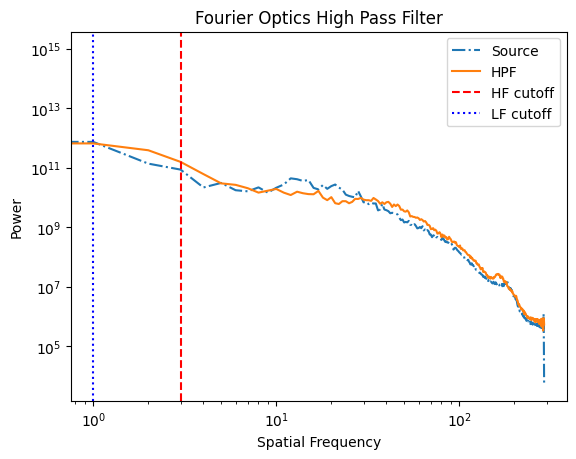

In [ ]:
### Lets radially average the Filtered FFTs and compare them for the HPF
power_source = np.abs(ex_fft_data)**2
power_hpf = np.abs(ex_hpf_fft_data)**2

def get_radial_profile(data):
    ny, nx = data.shape
    y, x = np.indices((ny, nx))
    cy, cx = ny//2, nx//2
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())

    radial_profile = tbin / nr

    return radial_profile

radial_power_source = get_radial_profile(power_source)
radial_power_hpf = get_radial_profile(power_hpf)

# ### Normal
# offset = 1
# radial_power_source = radial_power_source / np.sum(radial_power_source[offset:])
# radial_power_lpf = radial_power_lpf / np.sum(radial_power_lpf[offset:])
# radial_power_hpf = radial_power_hpf / np.sum(radial_power_hpf[offset:])


half_power = radial_power_hpf[0] / 2

cutoff_idx = np.where(radial_power_hpf < half_power)[0][0]
print(cutoff_idx)

def get_hf_ratio(radial_power,cutoff=20, offset=1):
    hf_power = np.sum(radial_power[cutoff:])
    total_power = np.sum(radial_power[offset:])

    hf_ratio = hf_power / total_power

    return hf_ratio

def get_hf_power_ratio_total(radial_power, source, cutoff=20, offset=1):
    hf_power = np.sum(radial_power[cutoff:])
    total_power = np.sum(source[offset:])

    hf_ratio = hf_power / total_power

    return hf_ratio

def half_point(radial_power, offset=1):

    half_peak_power = radial_power[0+offset]/2

    cutoff_idx = np.where(radial_power < half_peak_power)[0][0]

    return cutoff_idx


def compute_hf_lf(power_array, cutoff, offset=1):
    """
    Computes HF and LF fractions relative to the total power of the array.
    power_array: 1D numpy array (radial power)
    cutoff: index separating low and high frequencies
    Returns: hf_fraction, lf_fraction
    """
    total = np.sum(power_array)
    lf = np.sum(power_array[offset:cutoff])
    hf = np.sum(power_array[cutoff:])
    return hf/total, lf/total

CUTOFF = 30
OFFSET = 1

CUTOFF = half_point(radial_power_hpf)
#print("hf_ratio for LPF", get_hf_ratio(radial_power_lpf,cutoff=CUTOFF))
#print("hf_ratio for Source", get_hf_ratio(radial_power_source,cutoff=CUTOFF))

print("HPF power ratio",get_hf_ratio(radial_power_hpf,cutoff=CUTOFF)/get_hf_ratio(radial_power_source,cutoff=CUTOFF))

print("HPF power ratio (relative to the source spectrum)", get_hf_power_ratio_total(radial_power_hpf,radial_power_source,cutoff=CUTOFF))

plt.semilogy(radial_power_source, linestyle="-.", label="Source")
plt.semilogy(radial_power_hpf, label="HPF")
plt.xlabel("Spatial Frequency")
plt.ylabel("Power")
plt.title("Fourier Optics High Pass Filter")
plt.axvline(CUTOFF, linestyle='--', color='red', label='HF cutoff')
plt.axvline(OFFSET, linestyle=':', color='blue', label='LF cutoff')
plt.legend()
#plt.xlim(0,100)
plt.xscale("log")

In [248]:
### Calculate some numbers

def compute_hf_lf(power_array, cutoff, offset=1):
    """
    Computes HF and LF fractions relative to the total power of the array.
    power_array: 1D numpy array (radial power)
    cutoff: index separating low and high frequencies
    Returns: hf_fraction, lf_fraction
    """
    total = np.sum(power_array[offset:])
    lf = np.sum(power_array[offset:cutoff])
    hf = np.sum(power_array[cutoff:])
    return hf/total, lf/total

radial_power_source = radial_power_source / np.sum(radial_power_source)
radial_power_lpf = radial_power_lpf / np.sum(radial_power_lpf)
radial_power_hpf = radial_power_hpf / np.sum(radial_power_hpf)

CUTOFF_LPF = half_point(radial_power_lpf)
CUTOFF_HPF = half_point(radial_power_hpf)
CUTOFF_source = half_point(radial_power_source)

hf_source, lf_source = compute_hf_lf(radial_power_source, CUTOFF_source)
hf_lpf, lf_lpf = compute_hf_lf(radial_power_lpf, CUTOFF)
hf_hpf, lf_hpf = compute_hf_lf(radial_power_hpf, CUTOFF)

print("CUTOFF_LPF", CUTOFF_LPF)
print("CUTOFF_HPF", CUTOFF_HPF)
print("CUTOFF_Source", CUTOFF_source)

hf_lpf_norm = hf_lpf / hf_source
hf_hpf_norm = hf_hpf / hf_source

print("HF / LF fractions:")
print(f"Source: HF={hf_source}, LF={lf_source}")
print(f"LPF:    HF={hf_lpf}, LF={lf_lpf}")
print(f"HPF:    HF={hf_hpf}, LF={lf_hpf}")
print("\nNormalized HF (relative to source):")
print(f"LPF: {hf_lpf_norm:.3f}")
print(f"HPF: {hf_hpf_norm:.3f}")

CUTOFF_LPF 3
CUTOFF_HPF 3
CUTOFF_Source 2
HF / LF fractions:
Source: HF=0.5554405379437886, LF=0.4445594620562114
LPF:    HF=0.41386390994807515, LF=0.5861360900519249
HPF:    HF=0.41386390994807515, LF=0.5861360900519249

Normalized HF (relative to source):
LPF: 0.745
HPF: 0.745


1
HPF power ratio 0.43345710165003576
HPF power ratio (relative to the source spectrum) 0.1167760507235085


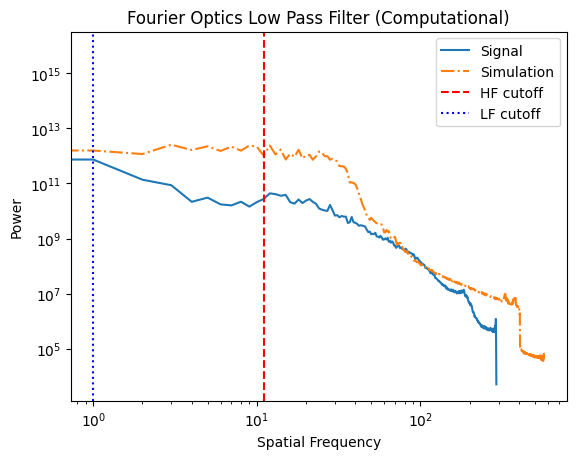

In [303]:
### Test with calculations

### Lets radially average the Filtered FFTs and compare them for the HPF
power_source = np.abs(fft_data)**2
power_hpf = np.abs(F_filtered)**2

def get_radial_profile(data):
    ny, nx = data.shape
    y, x = np.indices((ny, nx))
    cy, cx = ny//2, nx//2
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())

    radial_profile = tbin / nr

    return radial_profile

radial_power_source = get_radial_profile(power_source)
radial_power_hpf = get_radial_profile(power_hpf)

# ### Normal
# offset = 1
# radial_power_source = radial_power_source / np.sum(radial_power_source[offset:])
# radial_power_lpf = radial_power_lpf / np.sum(radial_power_lpf[offset:])
# radial_power_hpf = radial_power_hpf / np.sum(radial_power_hpf[offset:])


half_power = radial_power_hpf[0] / 2

cutoff_idx = np.where(radial_power_hpf < half_power)[0][0]
print(cutoff_idx)

def get_hf_ratio(radial_power,cutoff=20, offset=1):
    hf_power = np.sum(radial_power[cutoff:])
    total_power = np.sum(radial_power[offset:])

    hf_ratio = hf_power / total_power

    return hf_ratio

def get_hf_power_ratio_total(radial_power, source, cutoff=20, offset=1):
    hf_power = np.sum(radial_power[cutoff:])
    total_power = np.sum(source[offset:])

    hf_ratio = hf_power / total_power

    return hf_ratio

def half_point(radial_power, offset=1):

    half_peak_power = radial_power[0+offset]/2

    cutoff_idx = np.where(radial_power < half_peak_power)[0][0]

    return cutoff_idx


def compute_hf_lf(power_array, cutoff, offset=1):
    """
    Computes HF and LF fractions relative to the total power of the array.
    power_array: 1D numpy array (radial power)
    cutoff: index separating low and high frequencies
    Returns: hf_fraction, lf_fraction
    """
    total = np.sum(power_array)
    lf = np.sum(power_array[offset:cutoff])
    hf = np.sum(power_array[cutoff:])
    return hf/total, lf/total

CUTOFF = 30
OFFSET = 1

CUTOFF = half_point(radial_power_hpf)
#print("hf_ratio for LPF", get_hf_ratio(radial_power_lpf,cutoff=CUTOFF))
#print("hf_ratio for Source", get_hf_ratio(radial_power_source,cutoff=CUTOFF))

print("HPF power ratio",get_hf_ratio(radial_power_hpf,cutoff=CUTOFF)/get_hf_ratio(radial_power_source,cutoff=CUTOFF))

print("HPF power ratio (relative to the source spectrum)", get_hf_power_ratio_total(radial_power_hpf,radial_power_source,cutoff=CUTOFF))
Signal_power_source = get_radial_profile(np.abs(ex_fft_data)**2)

plt.semilogy(Signal_power_source, linestyle="-", label="Signal")
plt.semilogy(radial_power_source, linestyle="-.", label="Simulation")
radial_power_hpf = np.clip(radial_power_hpf, 1e-4, 1e22)
#plt.semilogy(radial_power_hpf, label="LPF")
plt.xlabel("Spatial Frequency")
plt.ylabel("Power")
plt.title("Fourier Optics Low Pass Filter (Computational)")
plt.axvline(CUTOFF, linestyle='--', color='red', label='HF cutoff')
plt.axvline(OFFSET, linestyle=':', color='blue', label='LF cutoff')
plt.legend()
#plt.xlim(1,100)
plt.xscale("log")

Text(0.5, 1.0, 'Low Pass Filter Effect on Calculation')

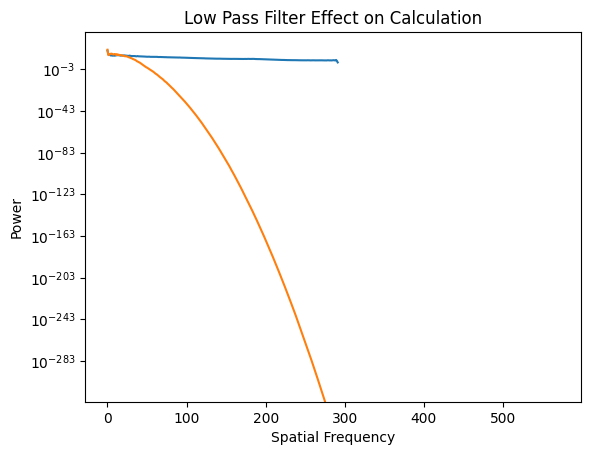

In [240]:
### Lets radially average the Filtered FFTs and compare them
power_source = np.abs(fft_data)**2
power_lpf = np.abs(F_filtered)**2

def get_radial_profile(data):
    ny, nx = data.shape
    y, x = np.indices((ny, nx))
    cy, cx = ny//2, nx//2
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())

    radial_profile = tbin / nr

    return radial_profile

radial_power_source = get_radial_profile(power)
radial_power_lpf = get_radial_profile(power_lpf)

plt.semilogy(radial_power, label="Source")
plt.semilogy(radial_power_lpf, label="LPF")
plt.xlabel("Spatial Frequency")
plt.ylabel("Power")
plt.title("Low Pass Filter Effect on Calculation")

[145 205 251 290 325 356 384 411 436 459 482 503 524 543 562]
[ 58  77 102 117 134 159 171 192 210 232 248 265 276 286]
Ring ratios 1.3275862068965518 1.4137931034482758
3.157894736842105 -38.15789473684208


Text(0.5, 1.0, 'Airy Pattern vs Reconstructed')

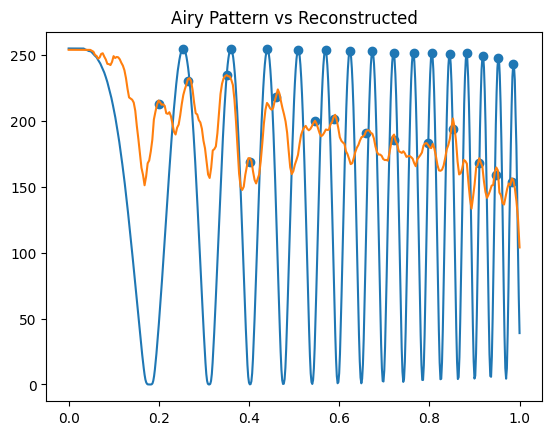

In [145]:
### Compare calculation to Simulation
r1 = np.linspace(0,1, len(get_radial_profile(data)))
r2 = np.linspace(0,1, len(get_radial_profile(experiment_data)))

profile_smooth = gaussian_filter1d(experiment_data, sigma=2)
peaks_exp, _ = find_peaks(get_radial_profile(profile_smooth), prominence=3)
peaks_theory, _ = find_peaks(get_radial_profile(data), prominence = 3)

point_x = []
point_y = []
for peak in peaks_theory:
    x_point = r1[peak]
    point_x.append(x_point)
    point_y.append(get_radial_profile(data)[peak])

point_x_ex = []
point_y_ex = []
for peak in peaks_exp:
    x_point = r2[peak]
    point_x.append(x_point)
    point_y.append(get_radial_profile(profile_smooth)[peak])

print(peaks_theory)
print(peaks_exp)

r1_exp = peaks_exp[0]
r2_exp = peaks_exp[1]
r1_th = peaks_theory[0]
r2_th = peaks_theory[1]

ratio_exp = r2_exp / r1_exp
ratio_th  = r2_th / r1_th
print("Ring ratios", ratio_exp, ratio_th)

r_exp_points = np.array([r1_exp, r2_exp])
r_th_points  = np.array([r1_th,  r2_th])

a, b = np.polyfit(r_exp_points, r_th_points, 1)

print(a, b)

#r_scaled = a * r2
r_scaled = r2

plt.plot(r1, get_radial_profile(data), label="Air Pattern")
plt.plot(r_scaled, get_radial_profile(experiment_data), label="Reconstruction")
plt.scatter(x=point_x,y=point_y)
plt.scatter(x=point_x_ex,y=point_y_ex)
plt.title("Airy Pattern vs Reconstructed")

[ 1.61218837 -0.06694367]


(0.0, 1.0)

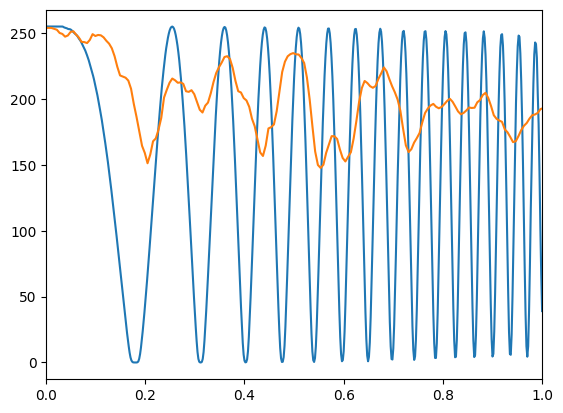

In [113]:
### Lets calibrate the scaling so the reconstructed airy patter matches what we put in

# r1_exp = r2[peaks_exp[0]]
# r2_exp = r2[peaks_exp[1]]
# r1_th = r1[peaks_theory[0]]
# r2_th = r1[peaks_theory[1]]

# ratio_exp = r2_exp / r1_exp
# ratio_th  = r2_th / r1_th
# print("Ring ratios", ratio_exp, ratio_th)

# r_exp_points = np.array([r1_exp, r2_exp])
# r_th_points  = np.array([r1_th,  r2_th])

# a, b = np.polyfit(r_exp_points, r_th_points, 1)

def fitter(degree, peaksx, peaksy, axis):

    coef = np.polyfit(r_exp_points, r_th_points, degree)
    print(coef)
    #return np.polyval(coef, axis)
    if degree == 1:
        return coef[0]*axis + coef[1]
    if degree == 2:
        #return coef[0]*axis**2 + coef[1]*axis + coef[2]
        return coef[1]*axis + coef[0]*axis**2 + coef[2]
#r_exp_points = r2[peaks_exp[0]][0:1]

DEGREE = 1
r_exp_points = [r2[index] for index in peaks_exp[0:DEGREE+1]]
r_th_points = [r1[index] for index in peaks_theory[0:DEGREE+1]]
r_scaled = fitter(DEGREE, r_exp_points, r_th_points, axis=r2)
#r_scaled = a * r2 + b

plt.plot(r1, get_radial_profile(data), label="Air Pattern")
plt.plot(r_scaled, get_radial_profile(experiment_data), label="Reconstruction")
plt.xlim(0,1)

#### Let just try 